In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA

In [5]:
df = pd.read_csv('../data/processed/scaled_marketing_campaign.csv')

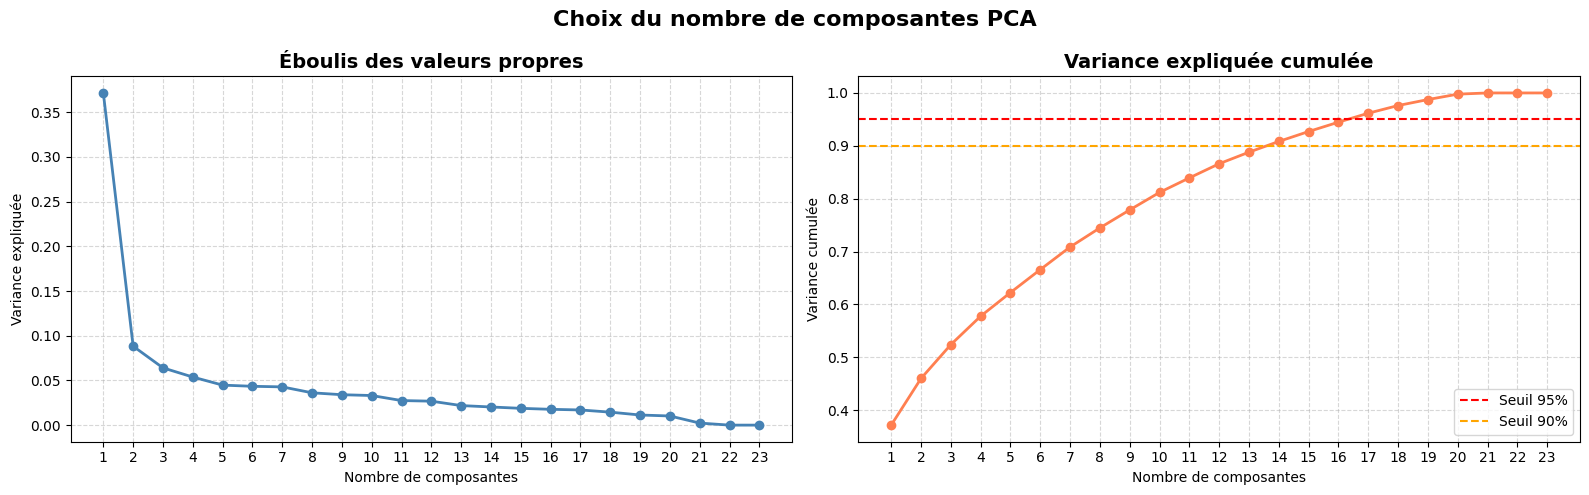

In [13]:
pca = PCA()
pca.fit(df)

#Eboulis des valeurs propres
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(range(1, len(pca.explained_variance_ratio_)+1),
             pca.explained_variance_ratio_,
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title("Éboulis des valeurs propres", 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel("Nombre de composantes")
axes[0].set_ylabel("Variance expliquée")
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_)+1))
axes[0].grid(True, linestyle='--', alpha=0.5)

#Variance cumulée
variance_cumulee = np.cumsum(pca.explained_variance_ratio_)

axes[1].plot(range(1, len(variance_cumulee)+1),
             variance_cumulee,
             marker='o', color='coral', linewidth=2)
axes[1].axhline(y=0.95, color='red', linestyle='--', 
                linewidth=1.5, label='Seuil 95%')
axes[1].axhline(y=0.90, color='orange', linestyle='--', 
                linewidth=1.5, label='Seuil 90%')
axes[1].set_title("Variance expliquée cumulée", 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée")
axes[1].set_xticks(range(1, len(variance_cumulee)+1))
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Choix du nombre de composantes PCA", 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

On constate que la diagramme des variances cumulées, nous nomtre que les 14 premières composantes principales expliquent plus de 90% de la variances donc on va faire notre pca avec 14 composantes principales. De plus le diagramme de l'ébouli des valeurs propres nous montre que le coude se trouve au niveau de la 2e composantes principales, donc pour la visualisation, on peut se limiter à 2 composantes principales

In [16]:
#PCA sur 14 composantes
MyPCA = PCA(n_components = 14)
df_pca = MyPCA.fit_transform(df)

df_pca_df = pd.DataFrame(
    df_pca,
    columns=[f'PC{i+1}' for i in range(14)]
)
print(f"Shape avant PCA : {df.shape}")
print(f"Shape après PCA : {df_pca_df.shape}")
print(f"Variance expliquée totale : {MyPCA.explained_variance_ratio_.sum()*100:.2f}%")
print(df_pca_df.head())

# Sauvegarde
df_pca_df.to_csv('../data/processed/pca_marketing_campaign.csv', index=False)
print("Dataset PCA sauvegardé")


Shape avant PCA : (2216, 23)
Shape après PCA : (2216, 14)
Variance expliquée totale : 90.83%
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  4.717069  0.631552 -1.836426  0.569492  1.185115  0.191816 -0.998195   
1 -3.067087 -0.725252  1.142047 -0.550296  0.559272 -0.587317 -1.513952   
2  1.902610 -0.281455 -0.087303 -1.002372 -1.097423 -0.857843  0.102743   
3 -2.891630 -1.087878 -0.269368  0.074454 -1.209844 -0.415601  0.410917   
4 -0.236862  0.506575  0.675778 -1.102998 -0.117304  1.379063  0.619658   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  
0  1.533293  0.318064  0.556561 -0.020129  0.486148 -1.710515 -0.767647  
1  0.681629 -0.979727  0.608608 -0.469788  0.078173  0.156572  0.147659  
2 -0.103906  0.733142 -1.622068 -0.336416  0.223185 -0.002621  0.586519  
3 -0.875643 -0.064680 -0.061627  0.094480 -0.036814 -0.379835  0.248772  
4 -1.693259  0.331476  0.780716  0.915608  0.457021 -0.616448 -0.498423  
Dataset PCA 